# BIVARIATE ANALYSIS
- 2 variable

## Load the data
- Here I load the pickle file that was saved in step1

In [27]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
# We load the pickle file so we have the correct data type

df = pd.read_pickle('data_MPG_clean.pkl')

In [29]:
# print 10 sample values

print(df.sample(10))

           mpg  cylinders  displacement  horsepower  weight  acceleration  \
134  16.000000          6           258         110    3632     18.000000   
99   18.000000          6           232         100    2945     16.000000   
307  26.796875          6           173         115    2700     12.898438   
232  16.000000          8           351         149    4335     14.500000   
397  31.000000          4           119          82    2720     19.406250   
350  34.687500          4           105          63    2215     14.898438   
365  20.203125          6           200          88    3060     17.093750   
259  20.796875          6           200          85    3070     16.703125   
240  30.500000          4            97          78    2190     14.101562   
362  24.203125          6           146         120    2930     13.796875   

     model_year  origin  
134          74     usa  
99           73     usa  
307          79     usa  
232          77     usa  
397          82     us

In [30]:
# lets see data types and memory usage

print(df.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           398 non-null    float16 
 1   cylinders     398 non-null    uint8   
 2   displacement  398 non-null    int16   
 3   horsepower    398 non-null    uint8   
 4   weight        398 non-null    int16   
 5   acceleration  398 non-null    float16 
 6   model_year    398 non-null    int8    
 7   origin        398 non-null    category
dtypes: category(1), float16(2), int16(2), int8(1), uint8(2)
memory usage: 5.0 KB
None


In [31]:
# Display the descriptive stats

print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  398.000000   398.000000   
mean    23.515625    5.454774    193.424623  104.462312  2970.424623   
std      7.816406    1.701004    104.271000   38.199230   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   76.000000  2223.750000   
50%     23.000000    4.000000    148.500000   95.000000  2803.500000   
75%     29.000000    8.000000    262.000000  125.000000  3608.000000   
max     46.593750    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    398.000000  398.000000  
mean      15.570312   76.010050  
std        2.757812    3.697627  
min        8.000000   70.000000  
25%       13.822266   73.000000  
50%       15.500000   76.000000  
75%       17.175781   79.000000  
max       24.796875   82.000000  


### **Bivariate Analysis**

* **Numerical (Continuous) vs. Numerical (Continuous)**:

  * Scatter plot: `mpg` vs `weight` (usually negative correlation).
  * Scatter plot: `mpg` vs `horsepower`.
  * Scatter plot: `mpg` vs `displacement`.

    
* **Categorical vs. Numerical**:

  * Boxplots: `mpg` across different `cylinders`.
  * Boxplots: `mpg` across different `origin`.
  * Trend of `mpg` over `model_year`.

---



# Numerical vs Numerical (Scatter Plot)

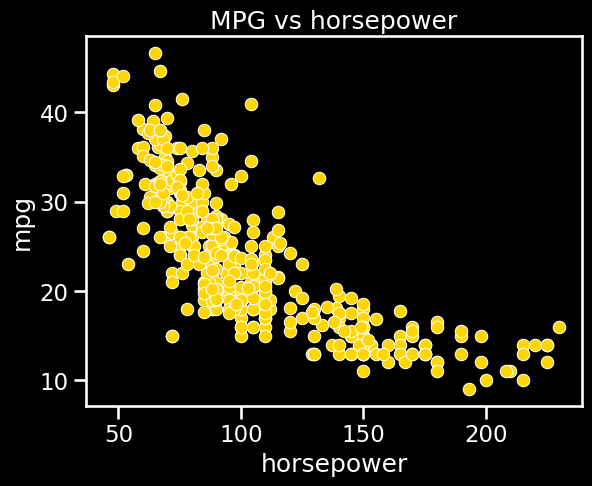

In [32]:
# step0: simple plot 

col = "horsepower"

sns.scatterplot(data=df, x=col, y='mpg')
plt.title(f'MPG vs {col}')
plt.show()

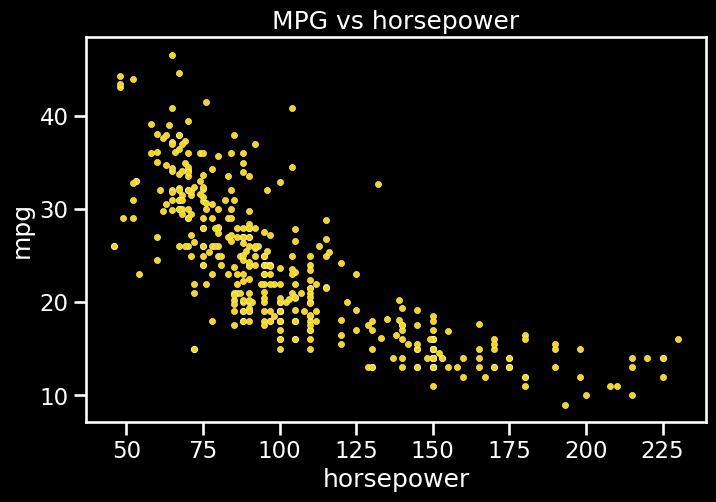

In [33]:
# step1: prettify above

plt.style.use("dark_background")  
# Optional: control Seaborn palette and font scale
sns.set_palette(["gold"])
sns.set_context("talk")
plt.figure(figsize=(8,5))

col = "horsepower"

# sns.regplot(data=df, x='horsepower', y='mpg') # Regression line shows trend clearly.
sns.scatterplot(data=df, x=col, y='mpg', s=20)
plt.title(f'MPG vs {col}')
plt.show()

# Observ:
# Downward trend → negative correlation
# Higher horsepower → lower mpg

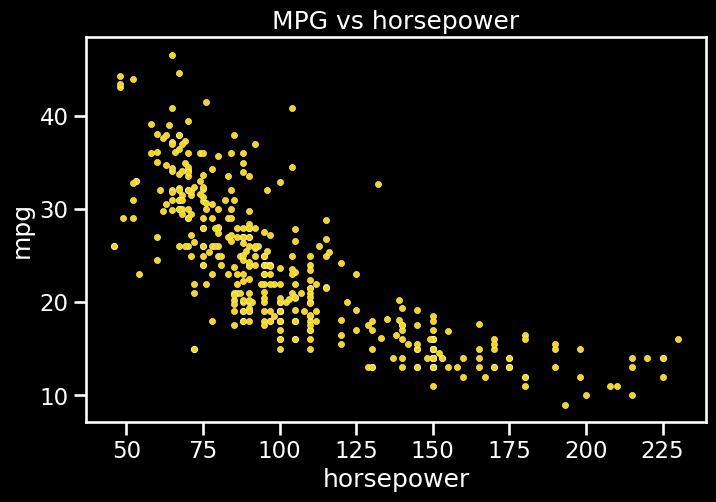

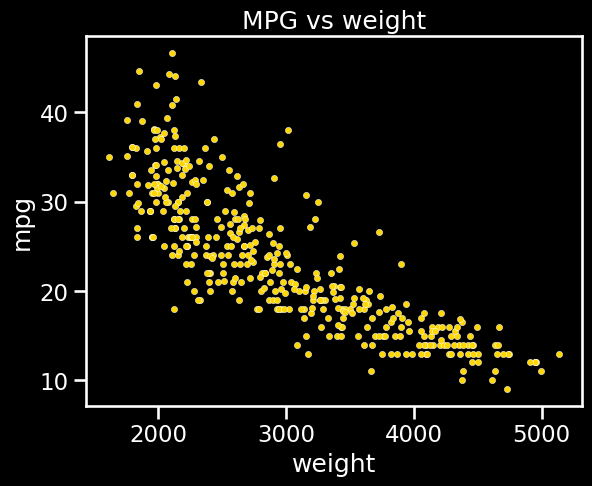

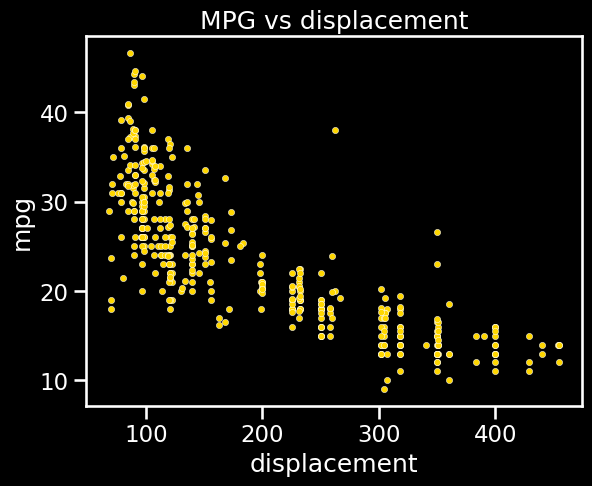

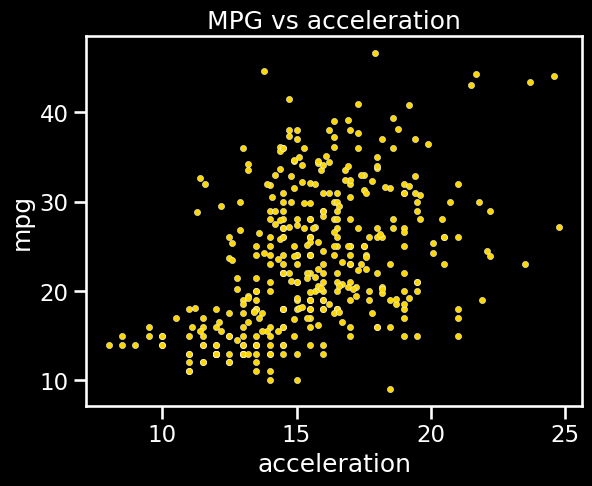

In [34]:
# step2: Use for loop

plt.style.use("dark_background")  
# Optional: control Seaborn palette and font scale
sns.set_palette(["gold"])
sns.set_context("talk")
plt.figure(figsize=(8,5))


columns = ["horsepower", "weight", "displacement", "acceleration"]

for col in columns:
    
    # sns.regplot(data=df, x='horsepower', y='mpg') # Regression line shows trend clearly.
    sns.scatterplot(data=df, x=col, y='mpg', s=20)
    plt.title(f'MPG vs {col}')
    plt.show()
    

# observ: As HP, weight, displacement increases, the MPG decrease.
# There appears almost no relation between acceleration and MPG

#  Categorical vs Numerical 

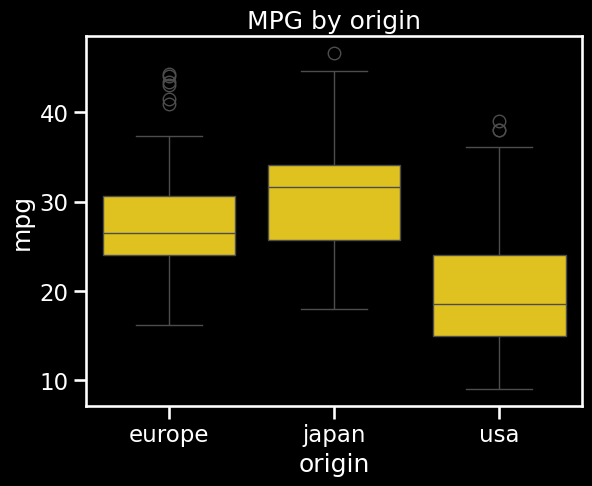

In [35]:
# step0: Here categorical column is origin

col = "origin"

sns.boxplot(data=df, x=col, y='mpg')
plt.title(f'MPG by {col}')
plt.show()

# Japanese cars generally have higher mpg
# US cars have lower mpg on average

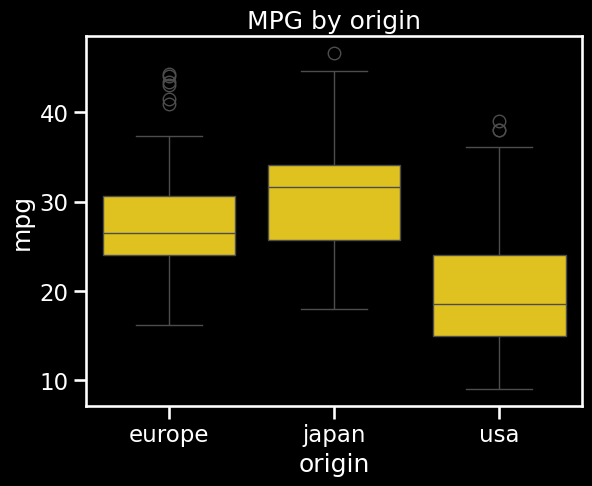

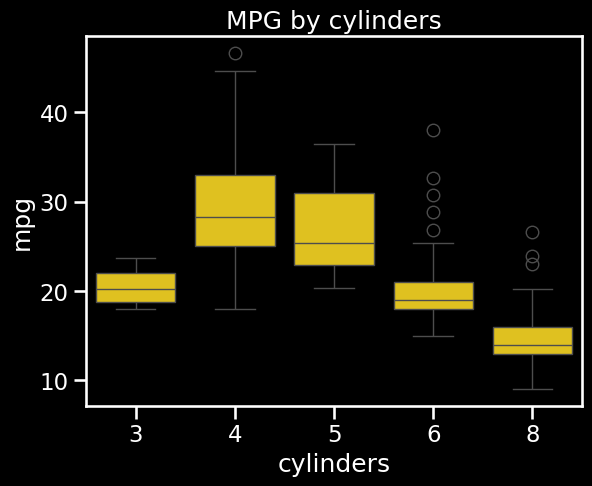

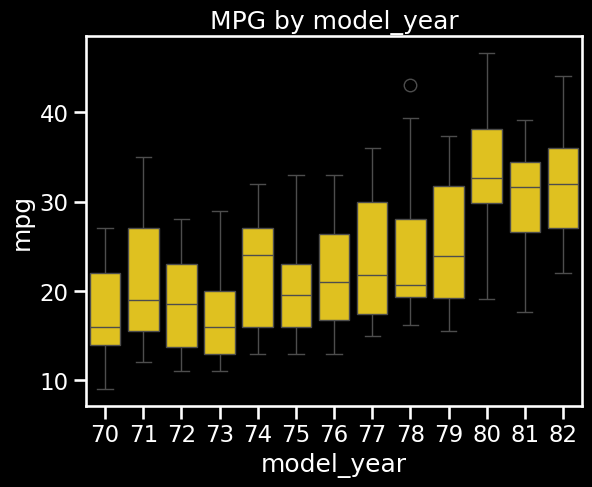

In [36]:
# step1: Now do MPG versus other columns

columns = ["origin", "cylinders", "model_year"]

for col in columns:
    sns.boxplot(data=df, x=col, y='mpg')
    plt.title(f'MPG by {col}')
    plt.show()

# Observ:
# MPG is highest when cylinders=4
# MPG is lowest when cylinders=8
# MPG vs model_year: The mpg has gone up with years


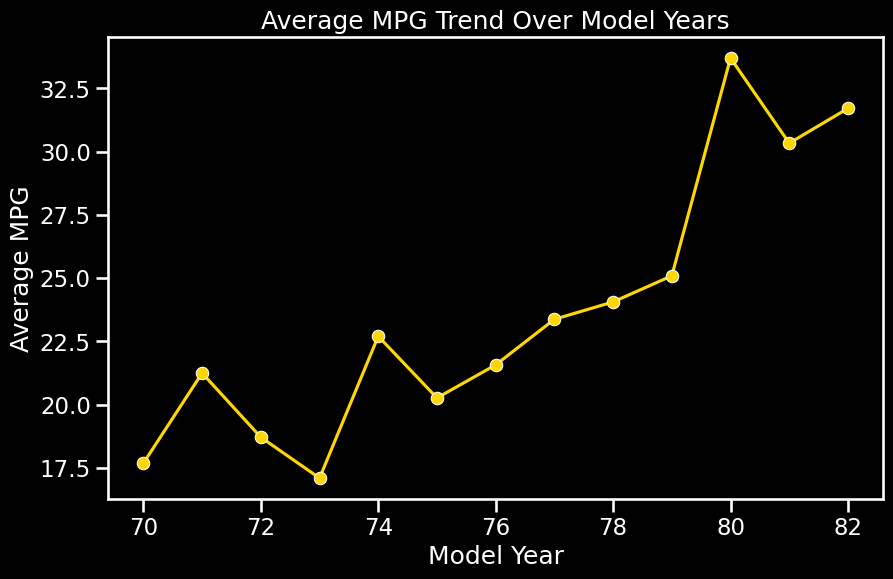

In [37]:
# step1: trend of MPG over the years

# Group by model_year and take mean mpg
yearly_trend = df.groupby("model_year")["mpg"].mean().reset_index()

# Plot
plt.figure(figsize=(10,6))
sns.lineplot(x="model_year", y="mpg", data=yearly_trend, marker="o")

plt.title("Average MPG Trend Over Model Years")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.show()

# observ: average MPG has increasing trend

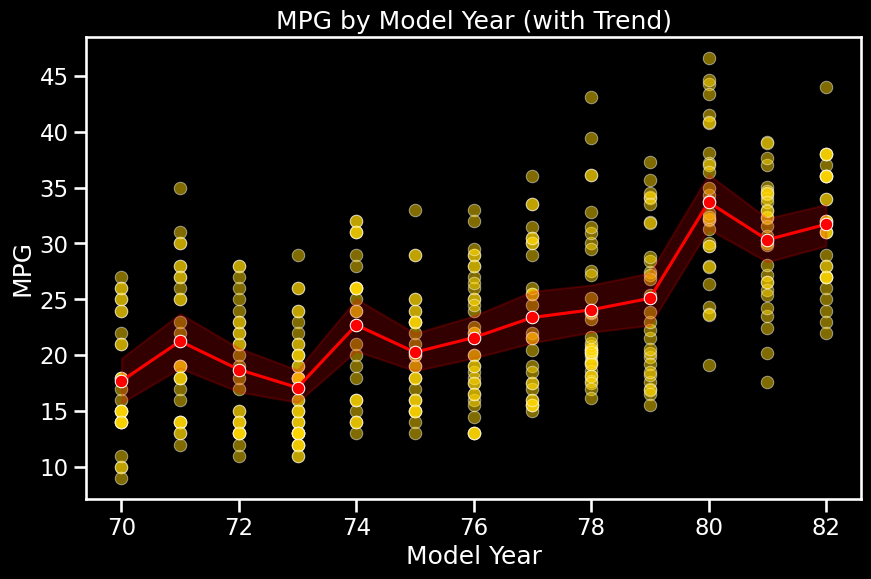

In [38]:
# step2: Lets add more info to trend of MPG over the years

plt.figure(figsize=(10,6))
sns.scatterplot(x="model_year", y="mpg", data=df, alpha=0.5)
sns.lineplot(x="model_year", y="mpg", data=df, estimator="mean", color="red", marker="o")

plt.title("MPG by Model Year (with Trend)")
plt.xlabel("Model Year")
plt.ylabel("MPG")
plt.show()

# obser: Each point = a car.
# Red line = average mpg trend.

# Use Violin Plot (Distribution + Density)

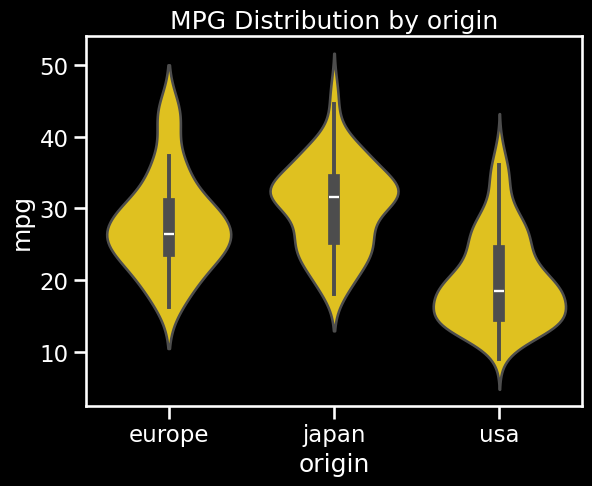

In [39]:

col = "origin"

sns.violinplot(data=df, x=col, y='mpg')
plt.title(f'MPG Distribution by {col}')
plt.show()

# Observ: Japan cars have better MPG
# For USA, most cars have MPG between 15 to 25

# Statistical Bivariate Insight (Correlation)

In [40]:
# step1: print numerical values

columns = ['mpg', 'horsepower', 'weight', 'acceleration']
corr_matrix = df[columns].corr()
print(corr_matrix)

                   mpg  horsepower    weight  acceleration
mpg           1.000000   -0.771542 -0.831733      0.420368
horsepower   -0.771542    1.000000  0.860676     -0.684393
weight       -0.831733    0.860676  1.000000     -0.417469
acceleration  0.420368   -0.684393 -0.417469      1.000000


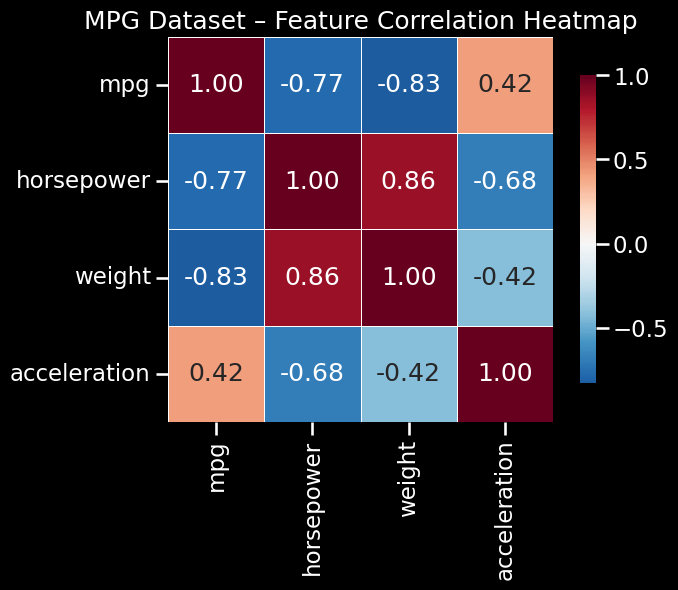

In [41]:
# step2: Now lets plot above using heatmap

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('MPG Dataset – Feature Correlation Heatmap')
plt.show()

# Pairwise scatter plot

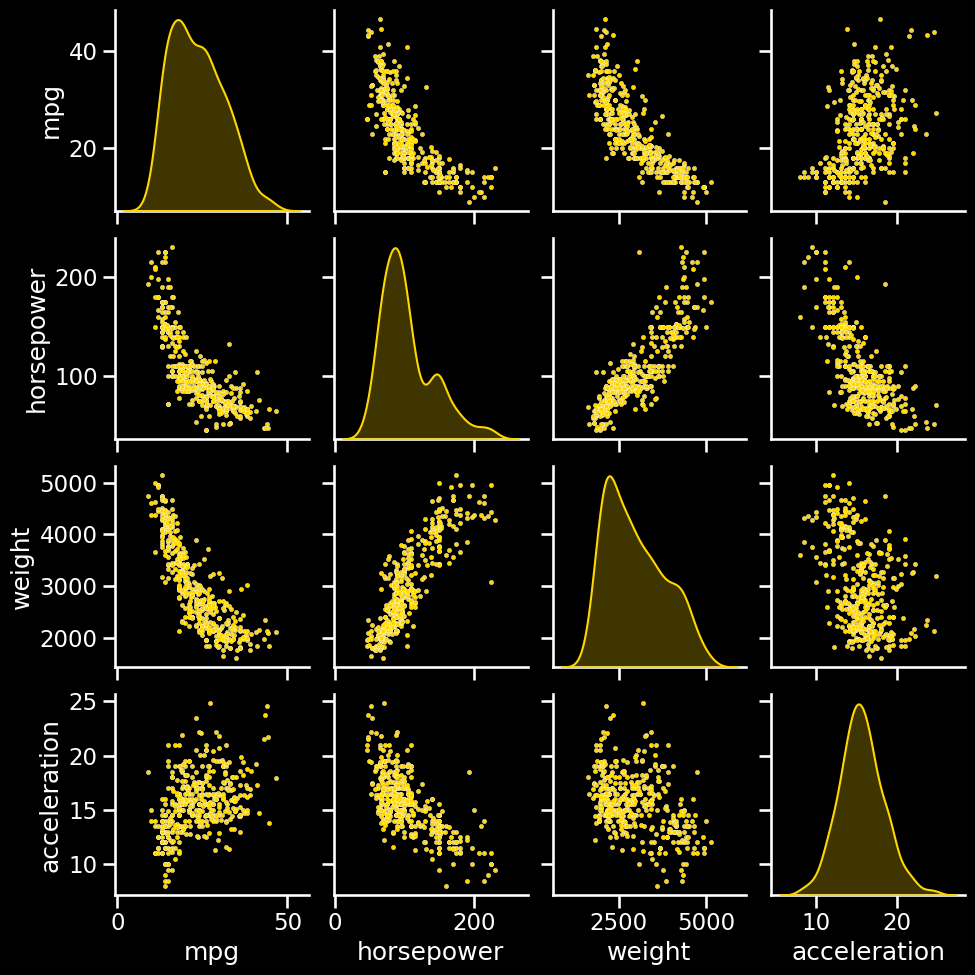

In [42]:

columns = ['mpg', 'horsepower', 'weight', 'acceleration']

sns.pairplot(
    df[columns],
    diag_kind='kde',
    plot_kws={'s': 10}   # marker size
)

plt.show()

# observ: As HP increases, acceleration decreases.

### **Feature Relationships**

* Regression plots of mpg with weight/horsepower.
* Compare slope for different `cylinders` groups.
* Interaction effect: cylinders + year on mpg.

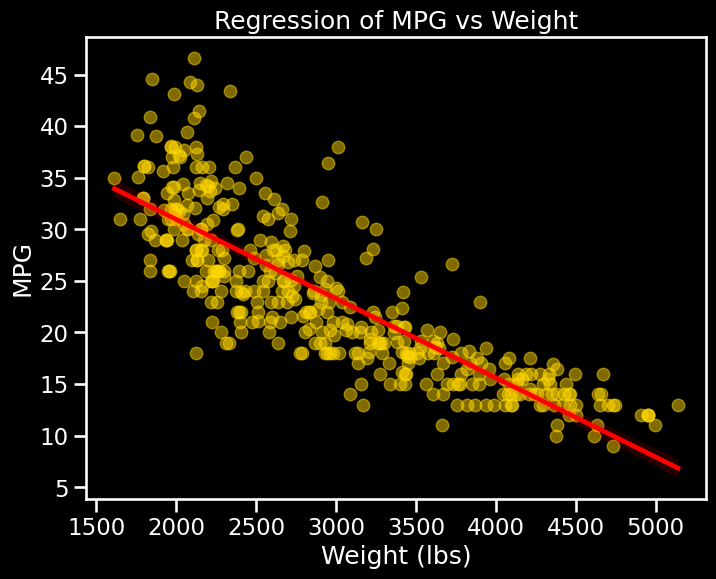

In [43]:
# Regression of MPG vs Weight

plt.figure(figsize=(8,6))
sns.regplot(x="weight", y="mpg", data=df, scatter_kws={"alpha":0.5}, line_kws={"color":"red"})
plt.title("Regression of MPG vs Weight")
plt.xlabel("Weight (lbs)")
plt.ylabel("MPG")
plt.show()

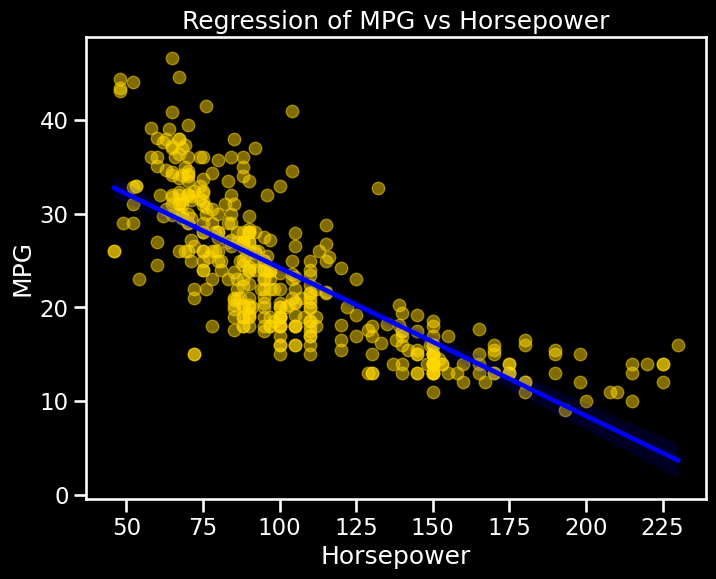

In [44]:
# Regression of MPG vs Horsepower
plt.figure(figsize=(8,6))
sns.regplot(x="horsepower", y="mpg", data=df, scatter_kws={"alpha":0.5}, line_kws={"color":"blue"})
plt.title("Regression of MPG vs Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()


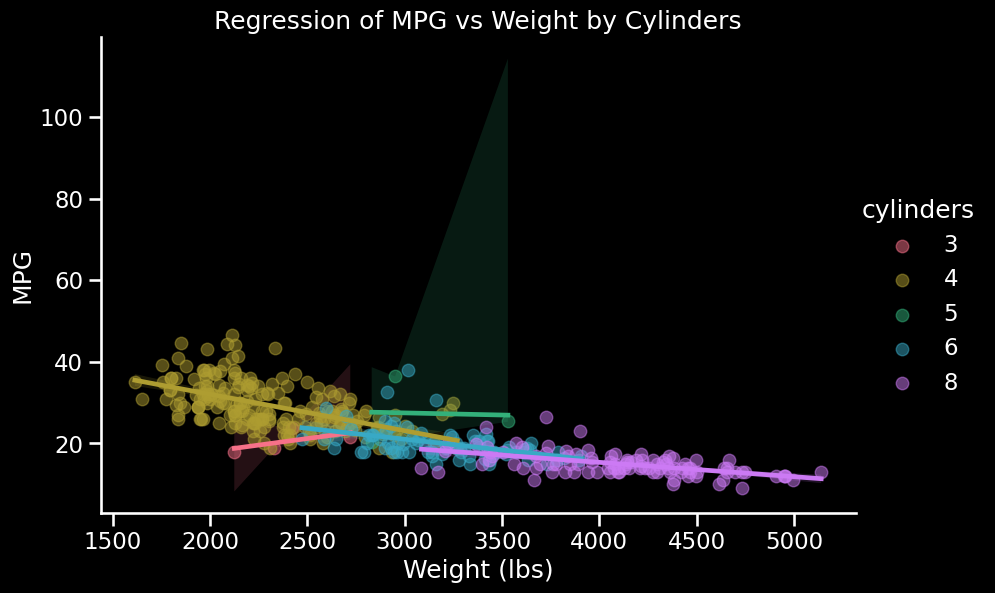